# PD, IRB capital, Vasicek losses, and optimal allocation

This notebook is a compact exploratory workspace for visualising the mapping

```text
PD -> Basel asset correlation R(PD)
PD -> Vasicek loss distribution F_L(. | PD, R(PD))
PD -> Basel IRB capital requirement K_IRB(PD)
PD, F_L, K_IRB -> optimal allocation alpha_star(PD)
```

The default setting is thesis-consistent: Basel-implied corporate asset correlation is used for both the Vasicek asymptotic single-risk-factor loss distribution and the Basel IRB capital calculation. Fixed-correlation runs are included only as sensitivity experiments.

## 1. Setup and parameters

The baseline parameters below are intentionally collected near the top so that the notebook can be used as an experimentation scratchpad. The main objective uses the analytical linear expected-shortfall penalty.

The `y` and `leverage` values in the setup cell are the single source of truth for the notebook. All main plots and sensitivity plots use those values unless the section is explicitly varying that parameter.


In [50]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

LGD = 0.45
M = 2.5
y = 0.05
lambda_penalty = 10.0
leverage = 10.0  # set to 1.0 for the unleveraged thesis baseline

rho_mode = "basel"  # options: "basel" or "fixed"
rho_fixed = 0.12    # only used when rho_mode == "fixed"

pd_min = 1e-4
pd_max = 0.20

pd_grid = np.linspace(pd_min, pd_max, 300)
alpha_grid = np.linspace(0, 1, 501)

# Coarser grids keep sensitivity and Monte Carlo comparison cells responsive.
sensitivity_pd_grid = np.linspace(pd_min, pd_max, 100)
sensitivity_alpha_grid = np.linspace(0, 1, 251)
coarse_pd_grid = np.linspace(pd_min, pd_max, 60)
coarse_alpha_grid = np.linspace(0, 1, 101)

rng = np.random.default_rng(42)

### Core functions

These functions keep the notebook modular. They accept scalars and arrays where useful, clip near-problematic boundaries, and keep the regulatory IRB calculation tied to the Basel correlation formula even when the Vasicek sensitivity experiment uses a fixed correlation.

In [51]:
def _asarray(x):
    """Return x as a NumPy array without losing scalar information upstream."""
    return np.asarray(x, dtype=float)


def _maybe_scalar(value, template):
    """Return a scalar when the original input was scalar, otherwise an array."""
    arr = np.asarray(value)
    return arr.item() if np.isscalar(template) else arr


def clip_pd(pd):
    """Clip probabilities of default away from 0 and 1.

    Works for scalar and array inputs. This prevents infinities in normal
    quantiles and logarithms.
    """
    clipped = np.clip(_asarray(pd), 1e-8, 1 - 1e-8)
    return _maybe_scalar(clipped, pd)


def clip_rho(rho):
    """Clip asset correlation away from degenerate 0 and 1 boundaries."""
    clipped = np.clip(_asarray(rho), 1e-8, 1 - 1e-8)
    return _maybe_scalar(clipped, rho)


def basel_correlation(pd):
    """Basel corporate asset correlation R(PD).

    R(PD) = 0.12 * w(PD) + 0.24 * (1 - w(PD)), where
    w(PD) = (1 - exp(-50 PD)) / (1 - exp(-50)).
    """
    pd_c = _asarray(clip_pd(pd))
    weight = (1 - np.exp(-50 * pd_c)) / (1 - np.exp(-50))
    rho = 0.12 * weight + 0.24 * (1 - weight)
    return _maybe_scalar(rho, pd)


def get_rho(pd, rho_mode="basel", rho_fixed=0.12):
    """Return Basel-implied or fixed asset correlation."""
    if rho_mode == "basel":
        return basel_correlation(pd)
    if rho_mode == "fixed":
        if np.isscalar(pd):
            return float(clip_rho(rho_fixed))
        return np.full_like(_asarray(pd), float(clip_rho(rho_fixed)), dtype=float)
    raise ValueError("rho_mode must be either 'basel' or 'fixed'")


def maturity_adjustment(pd, M=2.5):
    """Basel maturity adjustment for corporate exposures."""
    pd_c = _asarray(clip_pd(pd))
    b = (0.11852 - 0.05478 * np.log(pd_c)) ** 2
    adj = (1 + (M - 2.5) * b) / (1 - 1.5 * b)
    return _maybe_scalar(adj, pd)


def k_irb(pd, lgd=LGD, M=M):
    """Basel IRB capital requirement per unit exposure.

    This always uses the Basel corporate asset correlation, because the
    correlation is part of the regulatory IRB capital formula.
    """
    pd_c = _asarray(clip_pd(pd))
    R = _asarray(clip_rho(basel_correlation(pd_c)))
    z = norm.ppf(pd_c) / np.sqrt(1 - R) + np.sqrt(R / (1 - R)) * norm.ppf(0.999)
    capital = lgd * (norm.cdf(z) - pd_c) * maturity_adjustment(pd_c, M=M)
    return _maybe_scalar(np.maximum(capital, 0), pd)


def vasicek_cdf(x, pd, rho):
    """CDF of the asymptotic Vasicek default-rate distribution."""
    x_arr = _asarray(x)
    pd_c = _asarray(clip_pd(pd))
    rho_c = _asarray(clip_rho(rho))
    x_c = np.clip(x_arr, 1e-12, 1 - 1e-12)
    cdf = norm.cdf((norm.ppf(x_c) * np.sqrt(1 - rho_c) - norm.ppf(pd_c)) / np.sqrt(rho_c))
    cdf = np.where(x_arr <= 0, 0.0, np.where(x_arr >= 1, 1.0, cdf))
    return _maybe_scalar(cdf, x)


def vasicek_quantile(q, pd, rho):
    """Quantile function for the asymptotic Vasicek default-rate distribution."""
    q_c = np.clip(_asarray(q), 1e-12, 1 - 1e-12)
    pd_c = _asarray(clip_pd(pd))
    rho_c = _asarray(clip_rho(rho))
    quantile = norm.cdf((norm.ppf(pd_c) + np.sqrt(rho_c) * norm.ppf(q_c)) / np.sqrt(1 - rho_c))
    return _maybe_scalar(quantile, q)


def vasicek_loss_from_factor(Y, pd, rho):
    """Conditional default rate L(Y; PD, rho) for systematic factor Y."""
    pd_c = _asarray(clip_pd(pd))
    rho_c = _asarray(clip_rho(rho))
    loss = norm.cdf((norm.ppf(pd_c) - np.sqrt(rho_c) * _asarray(Y)) / np.sqrt(1 - rho_c))
    return _maybe_scalar(loss, Y)


def vasicek_expected_shortfall_above_threshold(x, pd, rho):
    """Analytical E[(L - x)^+] for Vasicek default-rate distribution.

    Uses the bivariate normal CDF expression. Edge cases follow directly from
    the payoff: if x <= 0, E[(L - x)^+] = E[L] - x = PD - x; if x >= 1, it is 0.
    Supports scalar x and array x for efficient grid searches at fixed PD/rho.
    """
    pd_c = float(clip_pd(pd))
    rho_c = float(clip_rho(rho))
    x_arr = _asarray(x)
    es = np.zeros_like(x_arr, dtype=float)

    below = x_arr <= 0
    above = x_arr >= 1
    middle = ~(below | above)

    es = np.where(below, pd_c - x_arr, es)
    if np.any(middle):
        x_mid = np.clip(x_arr[middle], 1e-12, 1 - 1e-12)
        y_x = (norm.ppf(pd_c) - np.sqrt(1 - rho_c) * norm.ppf(x_mid)) / np.sqrt(rho_c)
        points = np.column_stack([np.full_like(y_x, norm.ppf(pd_c)), y_x])
        joint_prob = multivariate_normal.cdf(
            points,
            mean=[0, 0],
            cov=[[1, np.sqrt(rho_c)], [np.sqrt(rho_c), 1]],
        )
        es[middle] = joint_prob - x_mid * norm.cdf(y_x)

    es = np.maximum(es, 0.0)
    return _maybe_scalar(es, x)


def shortfall_threshold(alpha, pd, y=y, lgd=LGD, leverage=leverage):
    """Default-rate threshold above which the capital shortfall is active.

    Leverage is risky loan exposure per unit of capital allocated. The baseline
    thesis version uses leverage=1, which recovers the unleveraged expression.
    """
    alpha_value = float(alpha)
    leverage_value = float(leverage)
    if alpha_value <= 0:
        return np.inf
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    kirb = k_irb(pd, lgd=lgd, M=M)
    numerator = (1 - alpha_value) + leverage_value * alpha_value * y - leverage_value * alpha_value * kirb
    denominator = leverage_value * alpha_value * lgd
    return numerator / denominator


def objective(
    alpha,
    pd,
    rho_mode="basel",
    rho_fixed=0.12,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    mc_draws=None,
):
    """Allocation objective U(alpha; PD), optionally with leverage.

    Leverage is risky loan exposure per unit of capital allocated. Terminal
    capital is 1 + leverage * alpha * (y - LGD * L). The default linear penalty
    uses the analytical Vasicek expected shortfall. The optional squared_mc
    penalty is exploratory and simulates systematic factor draws to estimate
    E[S^2]. Scalar alpha returns a float; array alpha returns a NumPy array.
    """
    leverage_value = float(leverage)
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    alpha_arr = _asarray(alpha)
    pd_c = float(clip_pd(pd))
    rho = float(clip_rho(get_rho(pd_c, rho_mode=rho_mode, rho_fixed=rho_fixed)))
    expected_terminal_capital = 1 + leverage_value * alpha_arr * (y - lgd * pd_c)

    utility = np.full_like(alpha_arr, 1.0, dtype=float)
    positive = alpha_arr > 0
    if np.any(positive):
        x = np.array([
            shortfall_threshold(a, pd_c, y=y, lgd=lgd, leverage=leverage_value)
            for a in alpha_arr[positive]
        ])
        if penalty_type == "linear":
            es = vasicek_expected_shortfall_above_threshold(x, pd_c, rho)
            expected_shortfall = leverage_value * alpha_arr[positive] * lgd * es
            penalty = lambda_penalty * expected_shortfall
        elif penalty_type == "squared_mc":
            if mc_draws is None:
                mc_draws = rng.standard_normal(50_000)
            losses = vasicek_loss_from_factor(mc_draws, pd_c, rho)
            shortfalls = (
                leverage_value
                * alpha_arr[positive, None]
                * lgd
                * np.maximum(losses[None, :] - x[:, None], 0)
            )
            penalty = lambda_penalty * np.mean(shortfalls ** 2, axis=1)
        else:
            raise ValueError("penalty_type must be either 'linear' or 'squared_mc'")
        utility[positive] = expected_terminal_capital[positive] - penalty

    return _maybe_scalar(utility, alpha)


def optimal_alpha(
    pd,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    penalty_type="linear",
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    mc_draws=None,
    return_curve=True,
):
    """Evaluate the objective over a grid and return the optimum.

    Returns (alpha_star, max_utility, objective_curve) when return_curve=True.
    """
    curve = objective(
        alpha_grid,
        pd,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
        mc_draws=mc_draws,
    )
    idx = int(np.nanargmax(curve))
    if return_curve:
        return float(alpha_grid[idx]), float(curve[idx]), curve
    return float(alpha_grid[idx]), float(curve[idx])


def percent_axis(ax, axis="x"):
    """Format an axis whose data are proportions as percentages."""
    formatter = plt.FuncFormatter(lambda value, _: f"{100 * value:.0f}%")
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


def rho_label(rho_mode=rho_mode, rho_fixed=rho_fixed):
    """Readable label for the current correlation mode."""
    if rho_mode == "basel":
        return "Basel-implied rho"
    return f"fixed rho = {rho_fixed:.2f}"

## 2. Basel IRB mapping

This section isolates the regulatory mappings: IRB capital, Basel corporate asset correlation, and expected charge-off rate. PD is shown in percentage terms to make the nonlinearities easier to read.

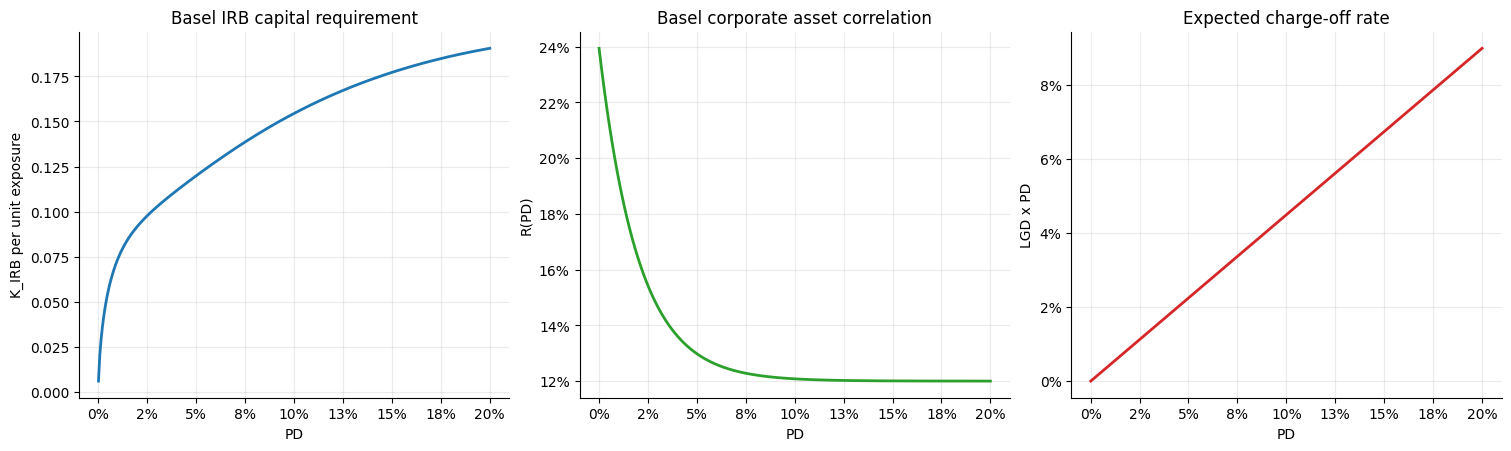

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

axes[0].plot(pd_grid, k_irb(pd_grid), color="tab:blue", lw=2)
axes[0].set_title("Basel IRB capital requirement")
axes[0].set_xlabel("PD")
axes[0].set_ylabel("K_IRB per unit exposure")
percent_axis(axes[0], "x")

axes[1].plot(pd_grid, basel_correlation(pd_grid), color="tab:green", lw=2)
axes[1].set_title("Basel corporate asset correlation")
axes[1].set_xlabel("PD")
axes[1].set_ylabel("R(PD)")
percent_axis(axes[1], "x")
percent_axis(axes[1], "y")

axes[2].plot(pd_grid, LGD * pd_grid, color="tab:red", lw=2)
axes[2].set_title("Expected charge-off rate")
axes[2].set_xlabel("PD")
axes[2].set_ylabel("LGD x PD")
percent_axis(axes[2], "x")
percent_axis(axes[2], "y")

plt.show()

## 3. Vasicek loss distribution

The Vasicek distribution describes the limiting portfolio default rate under a one-factor Gaussian credit model. In the baseline mode, each PD uses its Basel-implied correlation. The fixed-rho option is useful for separating correlation intuition from the Basel mapping.

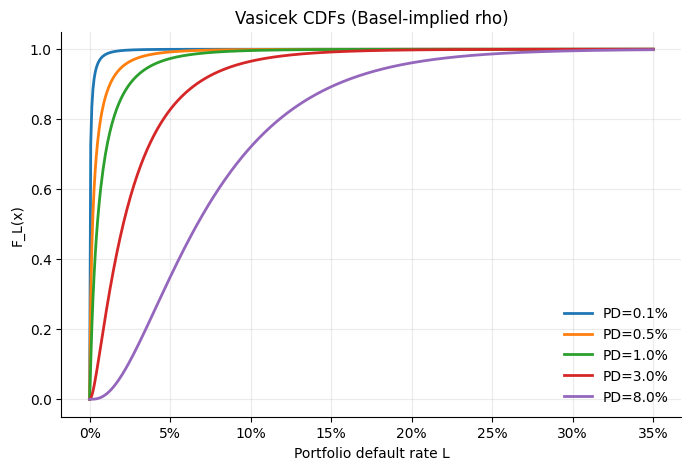

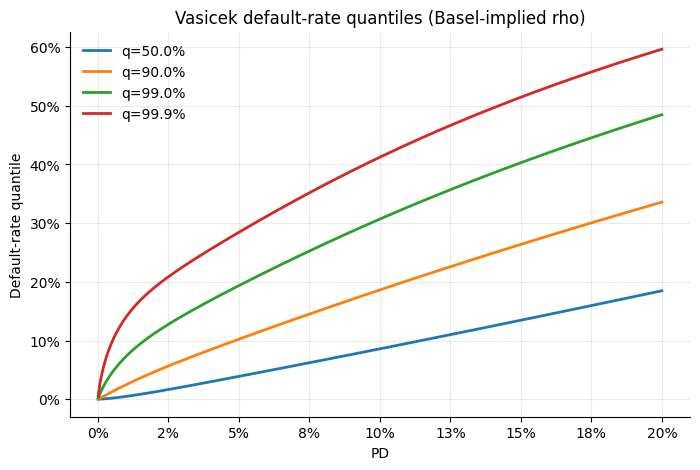

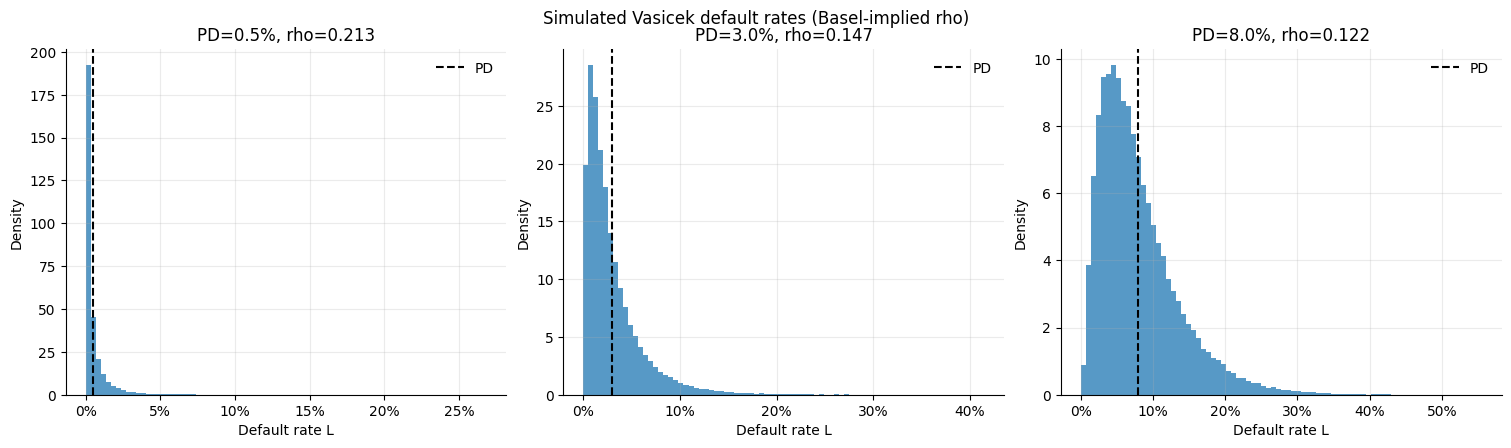

In [53]:
selected_pds = [0.001, 0.005, 0.01, 0.03, 0.08]
x_grid = np.linspace(0, 0.35, 500)
quantile_levels = [0.50, 0.90, 0.99, 0.999]

fig, ax = plt.subplots(figsize=(8, 5))
for pd_value in selected_pds:
    rho_value = get_rho(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    ax.plot(x_grid, vasicek_cdf(x_grid, pd_value, rho_value), lw=2, label=f"PD={100*pd_value:.1f}%")

ax.set_title(f"Vasicek CDFs ({rho_label()})")
ax.set_xlabel("Portfolio default rate L")
ax.set_ylabel("F_L(x)")
percent_axis(ax, "x")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for q in quantile_levels:
    q_values = np.array([
        vasicek_quantile(q, pd_value, get_rho(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed))
        for pd_value in pd_grid
    ])
    ax.plot(pd_grid, q_values, lw=2, label=f"q={100*q:.1f}%")

ax.set_title(f"Vasicek default-rate quantiles ({rho_label()})")
ax.set_xlabel("PD")
ax.set_ylabel("Default-rate quantile")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
sim_pds = [0.005, 0.03, 0.08]
Y_sim = rng.standard_normal(80_000)

for ax, pd_value in zip(axes, sim_pds):
    rho_value = get_rho(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    losses = vasicek_loss_from_factor(Y_sim, pd_value, rho_value)
    ax.hist(losses, bins=80, density=True, color="tab:blue", alpha=0.75)
    ax.axvline(pd_value, color="black", lw=1.5, ls="--", label="PD")
    ax.set_title(f"PD={100*pd_value:.1f}%, rho={rho_value:.3f}")
    ax.set_xlabel("Default rate L")
    ax.set_ylabel("Density")
    percent_axis(ax, "x")
    ax.legend()

fig.suptitle(f"Simulated Vasicek default rates ({rho_label()})", y=1.03)
plt.show()

## 4. Shortfall threshold

The threshold `x(alpha, PD, leverage)` is the realised portfolio default rate above which the regulatory-capital shortfall becomes active. Leverage belongs in this threshold because it scales risky exposure, terminal capital, and required regulatory capital. When `leverage = 1.0`, the expression collapses to the unleveraged thesis baseline.

When the threshold is above 1, shortfall is essentially impossible. When it is below 0, shortfall is always active.


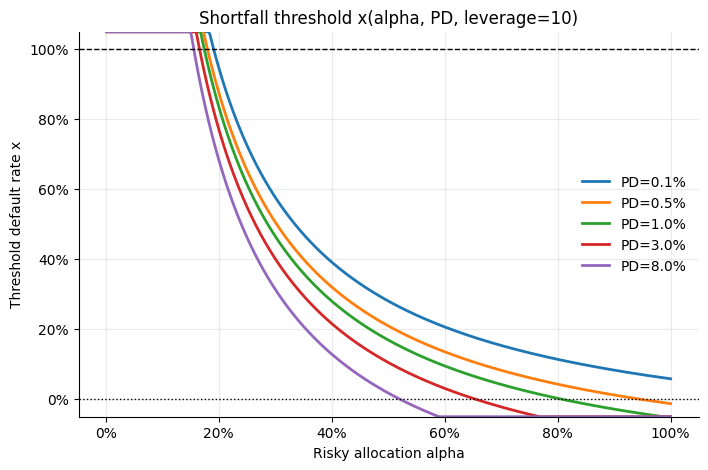

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
alpha_positive = alpha_grid[1:]

for pd_value in selected_pds:
    thresholds = np.array([
        shortfall_threshold(alpha, pd_value, y=y, lgd=LGD, leverage=leverage)
        for alpha in alpha_positive
    ])
    visible_thresholds = np.clip(thresholds, -0.05, 1.05)
    ax.plot(alpha_positive, visible_thresholds, lw=2, label=f"PD={100*pd_value:.1f}%")

ax.axhline(1, color="black", lw=1, ls="--")
ax.axhline(0, color="black", lw=1, ls=":")
ax.set_title(f"Shortfall threshold x(alpha, PD, leverage={leverage:g})")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("Threshold default rate x")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.show()

## 5. Expected shortfall term

The expected shortfall term is `E[(L - x(alpha, PD))^+]`. It rises when either the threshold falls or the Vasicek tail becomes heavier. This is the analytical Vasicek expression used in the main objective.

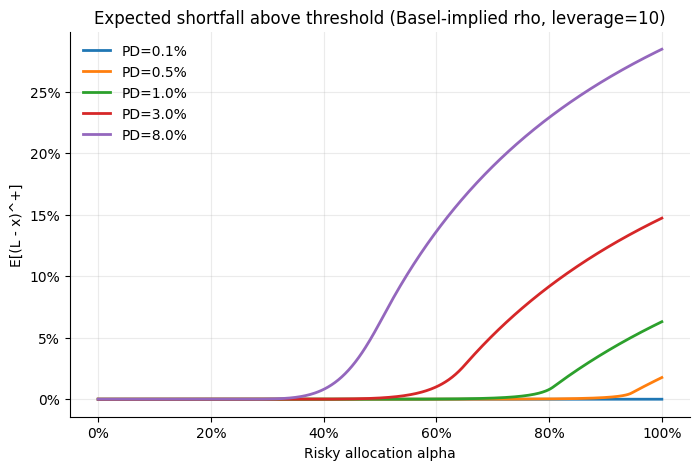

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))

for pd_value in selected_pds:
    rho_value = get_rho(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    es_values = np.array([
        vasicek_expected_shortfall_above_threshold(
            shortfall_threshold(alpha, pd_value, y=y, lgd=LGD, leverage=leverage),
            pd_value,
            rho_value,
        ) if alpha > 0 else 0.0
        for alpha in alpha_grid
    ])
    ax.plot(alpha_grid, es_values, lw=2, label=f"PD={100*pd_value:.1f}%")

ax.set_title(f"Expected shortfall above threshold ({rho_label()}, leverage={leverage:g})")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("E[(L - x)^+]")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

## 6. Allocation objective

For each selected PD, the objective balances expected risky return against expected credit losses and the regulatory shortfall penalty. The marker shows the grid-search optimum.

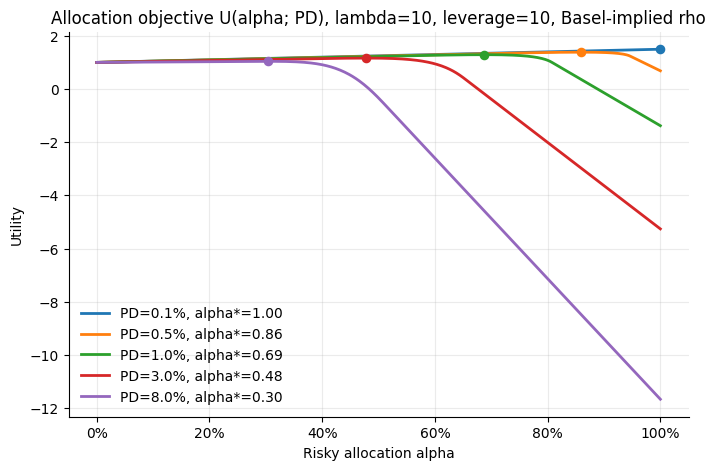

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))

for pd_value in selected_pds:
    alpha_star, max_u, curve = optimal_alpha(
        pd_value,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage
    )
    ax.plot(alpha_grid, curve, lw=2, label=f"PD={100*pd_value:.1f}%, alpha*={alpha_star:.2f}")
    ax.scatter([alpha_star], [max_u], s=35, zorder=3)

ax.set_title(f"Allocation objective U(alpha; PD), lambda={lambda_penalty:g}, leverage={leverage:g}, {rho_label()}")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("Utility")
percent_axis(ax, "x")
ax.legend()
plt.show()

## 7. PD-to-optimal-allocation mapping

The main object of interest is the decision rule `PD -> alpha_star`. The companion panels show the expected charge-off rate, IRB capital requirement, and maximum utility at the chosen allocation.

In [57]:
allocation_rows = []
for pd_value in pd_grid:
    alpha_star, max_u = optimal_alpha(
        pd_value,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        return_curve=False,
        leverage=leverage
    )
    allocation_rows.append({
        "PD": pd_value,
        "alpha_star": alpha_star,
        "max_utility": max_u,
        "expected_charge_off": LGD * pd_value,
        "K_IRB": k_irb(pd_value),
        "rho": get_rho(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed),
    })

allocation_df = pd.DataFrame(allocation_rows)
allocation_df.head()

,PD,alpha_star,max_utility,expected_charge_off,K_IRB,rho
0,0.000100,1.0,1.499550,0.000045,0.006026,0.239401
1,0.000769,1.0,1.496479,0.000346,0.020322,0.235476
2,0.001437,1.0,1.492798,0.000647,0.029224,0.231680
3,0.002106,1.0,1.486624,0.000948,0.036111,0.228008
4,0.002774,1.0,1.472400,0.001248,0.041789,0.224457


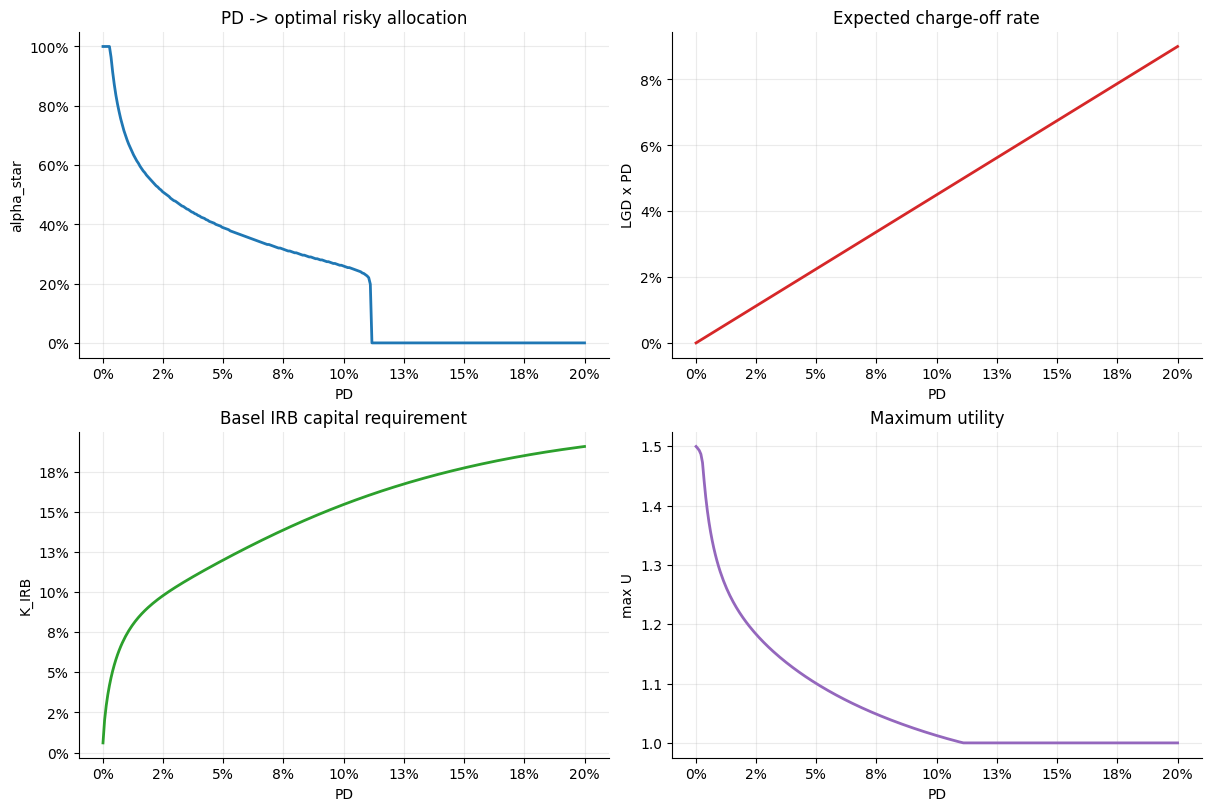

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(allocation_df["PD"], allocation_df["alpha_star"], color="tab:blue", lw=2)
axes[0, 0].set_title("PD -> optimal risky allocation")
axes[0, 0].set_xlabel("PD")
axes[0, 0].set_ylabel("alpha_star")
percent_axis(axes[0, 0], "x")
percent_axis(axes[0, 0], "y")

axes[0, 1].plot(allocation_df["PD"], allocation_df["expected_charge_off"], color="tab:red", lw=2)
axes[0, 1].set_title("Expected charge-off rate")
axes[0, 1].set_xlabel("PD")
axes[0, 1].set_ylabel("LGD x PD")
percent_axis(axes[0, 1], "x")
percent_axis(axes[0, 1], "y")

axes[1, 0].plot(allocation_df["PD"], allocation_df["K_IRB"], color="tab:green", lw=2)
axes[1, 0].set_title("Basel IRB capital requirement")
axes[1, 0].set_xlabel("PD")
axes[1, 0].set_ylabel("K_IRB")
percent_axis(axes[1, 0], "x")
percent_axis(axes[1, 0], "y")

axes[1, 1].plot(allocation_df["PD"], allocation_df["max_utility"], color="tab:purple", lw=2)
axes[1, 1].set_title("Maximum utility")
axes[1, 1].set_xlabel("PD")
axes[1, 1].set_ylabel("max U")
percent_axis(axes[1, 1], "x")

plt.show()

## 8. Sensitivity experiments

These experiments are meant for intuition. The Basel-implied correlation case is the thesis-consistent baseline; fixed correlations are useful for diagnosing how much of the allocation rule comes from correlation assumptions versus expected losses and regulatory capital. The sensitivity cells use coarser PD and alpha grids so they remain quick to rerun while preserving the shape of the decision rule.
Unless a section is explicitly varying leverage, these sensitivity plots use the top-level `leverage` value from the setup cell.


### 8.1 Different penalty weights

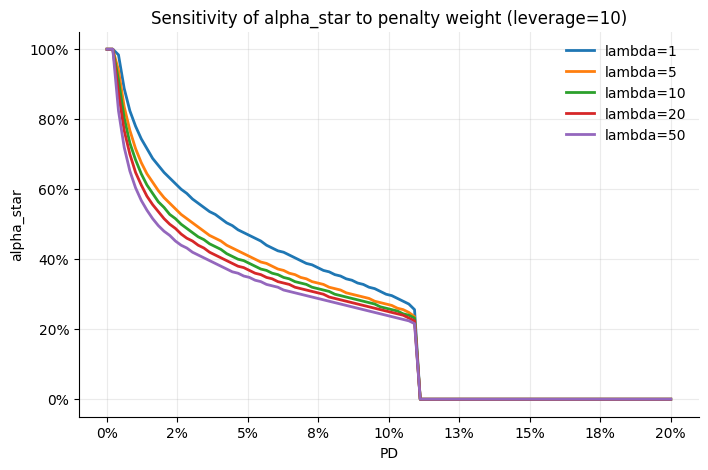

In [59]:
def alpha_star_curve(pd_values, alpha_grid=alpha_grid, leverage=leverage, **kwargs):
    """Convenience helper for sensitivity plots.

    Uses the top-level leverage by default; pass leverage=... only in sections
    that intentionally vary leverage.
    """
    return np.array([
        optimal_alpha(
            pd_value,
            alpha_grid=alpha_grid,
            leverage=leverage,
            return_curve=False,
            **kwargs,
        )[0]
        for pd_value in pd_values
    ])

lambda_values = [1, 5, 10, 20, 50]

fig, ax = plt.subplots(figsize=(8, 5))
for lam in lambda_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y,
        lambda_penalty=lam,
        alpha_grid=sensitivity_alpha_grid,
        leverage=leverage
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"lambda={lam:g}")

ax.set_title(f"Sensitivity of alpha_star to penalty weight (leverage={leverage:g})")
ax.set_xlabel("PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

### 8.2 Basel versus fixed asset correlation

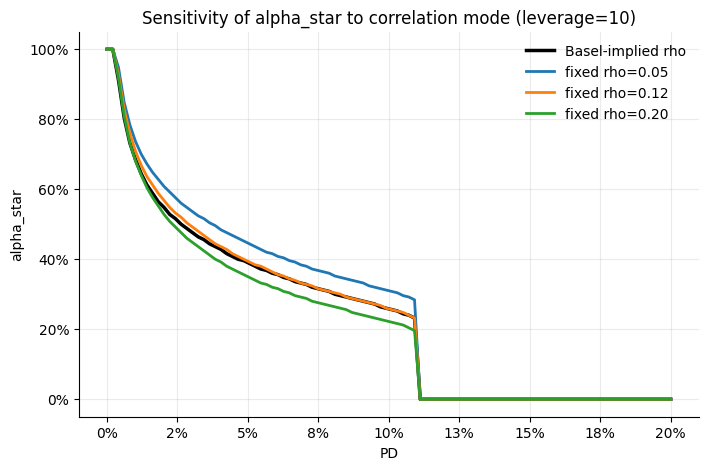

In [60]:
fixed_rho_values = [0.05, 0.12, 0.20]

fig, ax = plt.subplots(figsize=(8, 5))
curve = alpha_star_curve(
    sensitivity_pd_grid,
    rho_mode="basel",
    rho_fixed=rho_fixed,
    penalty_type="linear",
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    alpha_grid=sensitivity_alpha_grid,
)
ax.plot(sensitivity_pd_grid, curve, lw=2.5, color="black", label="Basel-implied rho")

for fixed_rho in fixed_rho_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="fixed",
        rho_fixed=fixed_rho,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"fixed rho={fixed_rho:.2f}")

ax.set_title(f"Sensitivity of alpha_star to correlation mode (leverage={leverage:g})")
ax.set_xlabel("PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

### 8.3 Different yields

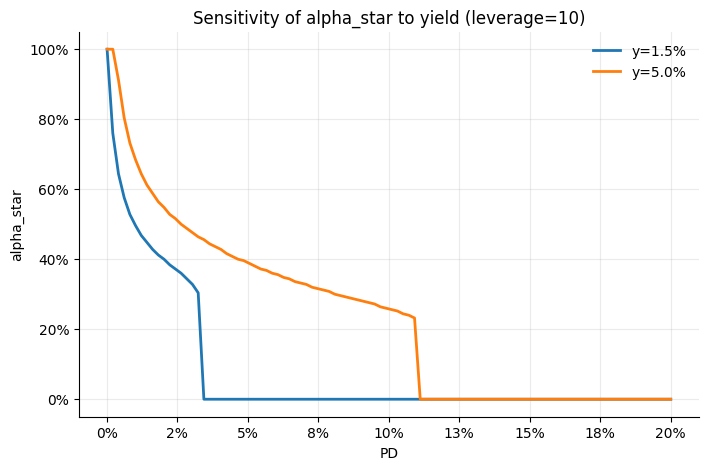

In [61]:
yield_values = list(dict.fromkeys([0.015, y, 0.05]))

fig, ax = plt.subplots(figsize=(8, 5))
for y_value in yield_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y_value,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"y={100*y_value:.1f}%")

ax.set_title(f"Sensitivity of alpha_star to yield (leverage={leverage:g})")
ax.set_xlabel("PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

## 9. Leverage sensitivity

The baseline thesis version is unleveraged with `leverage = 1.0`. In this optional sensitivity, leverage is interpreted as risky loan exposure per unit of capital allocated: exposure is `leverage * alpha`. Higher leverage increases both expected terminal capital exposure and the regulatory shortfall exposure; the plot shows how that changes the implied `PD -> alpha_star` rule.

This is the only sensitivity section that intentionally overrides the top-level `leverage` value, because leverage is the parameter being varied. It still uses the top-level `y` and `lambda_penalty`.


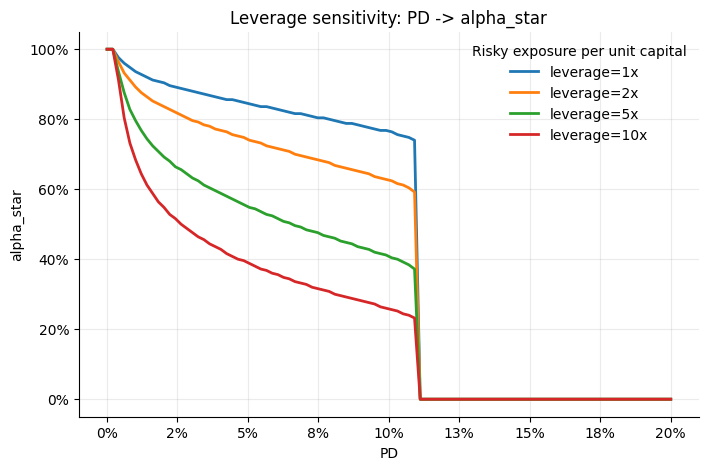

In [62]:
leverage_values = [1, 2, 5, 10]

fig, ax = plt.subplots(figsize=(8, 5))
for leverage_value in leverage_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage_value,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"leverage={leverage_value:g}x")

ax.set_title("Leverage sensitivity: PD -> alpha_star")
ax.set_xlabel("PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(title="Risky exposure per unit capital")
plt.show()


## Section 10: Forecast error, allocation distortion and regret

This section separates the prediction step from the evaluation step. The forecasted PD determines the allocation chosen by the model. The true PD determines the realised consequences of that allocation.

This distinction is important for regret. The oracle allocation is the allocation that would be chosen if the true PD were known. The forecast-based allocation is the allocation chosen using the model's predicted PD. Both allocations are then evaluated under the same true-PD objective. This ensures that regret measures the utility loss caused by using an imperfect forecast, rather than allowing the forecast to also change the evaluation standard.

Under this corrected definition, regret is non-negative up to numerical tolerance because the oracle allocation is optimal under the same objective used to evaluate the forecast-based allocation.

```text
pd_hat chooses the action.
pd_true judges the consequence.
```

Unless explicitly varied, this section uses the top-level `y`, `lambda_penalty`, and `leverage` values from the setup cell.

In [63]:
def objective_under_true_pd(
    alpha,
    pd_true,
    rho_mode="basel",
    rho_fixed=0.12,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    mc_draws=None,
):
    """Evaluate utility under the true PD environment.

    This function is used for regret evaluation. The allocation alpha may have
    been chosen using a forecasted PD, but once alpha is fixed, its consequence
    is evaluated using the true PD.

    Therefore:
    - expected realised losses use pd_true;
    - the Vasicek loss distribution uses pd_true;
    - the Basel IRB capital requirement uses pd_true;
    - the shortfall threshold uses k_irb(pd_true).
    """
    leverage_value = float(leverage)
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    alpha_arr = _asarray(alpha)
    pd_true_c = float(clip_pd(pd_true))
    expected_terminal_capital = 1 + leverage_value * alpha_arr * (y - lgd * pd_true_c)
    utility = np.full_like(alpha_arr, 1.0, dtype=float)

    positive = alpha_arr > 0
    if np.any(positive):
        kirb_true = k_irb(pd_true_c, lgd=lgd, M=M)
        x = (
            (1 - alpha_arr[positive])
            + leverage_value * alpha_arr[positive] * y
            - leverage_value * alpha_arr[positive] * kirb_true
        ) / (leverage_value * alpha_arr[positive] * lgd)

        rho_true = get_rho(pd_true_c, rho_mode=rho_mode, rho_fixed=rho_fixed)

        if penalty_type == "linear":
            es_true = vasicek_expected_shortfall_above_threshold(x, pd_true_c, rho_true)
            utility[positive] = expected_terminal_capital[positive] - lambda_penalty * leverage_value * alpha_arr[positive] * lgd * es_true
        elif penalty_type == "squared_mc":
            if mc_draws is None:
                mc_draws = rng.standard_normal(50_000)
            losses = vasicek_loss_from_factor(mc_draws, pd_true_c, rho_true)
            shortfalls = (
                leverage_value
                * alpha_arr[positive, None]
                * lgd
                * np.maximum(losses[None, :] - x[:, None], 0)
            )
            utility[positive] = expected_terminal_capital[positive] - lambda_penalty * np.mean(shortfalls ** 2, axis=1)
        else:
            raise ValueError("penalty_type must be either 'linear' or 'squared_mc'")

    return _maybe_scalar(utility, alpha)


def optimal_alpha_for_decision_pd(
    pd_decision,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    return_curve=True,
):
    """Choose alpha as if pd_decision were the relevant PD.

    This is the allocation rule used by a forecast-based model.
    """
    return optimal_alpha(
        pd_decision,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type=penalty_type,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        return_curve=return_curve,
    )


def regret_from_pd_forecast(
    pd_true,
    pd_hat,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
):
    """Compute decision-theoretic regret from using pd_hat instead of pd_true.

    pd_hat is used to choose the allocation. pd_true is used to evaluate the consequence.
    """
    pd_true_c = float(clip_pd(pd_true))
    pd_hat_c = float(clip_pd(pd_hat))

    alpha_oracle, _, _ = optimal_alpha_for_decision_pd(
        pd_true_c,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )
    alpha_hat, _, _ = optimal_alpha_for_decision_pd(
        pd_hat_c,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )

    utility_oracle = objective_under_true_pd(
        alpha_oracle,
        pd_true=pd_true_c,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )
    utility_hat = objective_under_true_pd(
        alpha_hat,
        pd_true=pd_true_c,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )

    regret_raw = float(utility_oracle - utility_hat)
    if regret_raw < -1e-9:
        raise ValueError(
            f"Negative regret detected: {regret_raw:.6g}. "
            f"pd_true={pd_true_c:.6g}, pd_hat={pd_hat_c:.6g}, "
            f"alpha_oracle={alpha_oracle:.6g}, alpha_hat={alpha_hat:.6g}"
        )
    regret = max(regret_raw, 0.0)

    return {
        "pd_true": pd_true_c,
        "pd_hat": pd_hat_c,
        "forecast_error": pd_hat_c - pd_true_c,
        "relative_error": (pd_hat_c - pd_true_c) / pd_true_c,
        "alpha_oracle": alpha_oracle,
        "alpha_hat": alpha_hat,
        "utility_oracle": utility_oracle,
        "utility_hat": utility_hat,
        "regret": regret,
    }


def evaluate_regret_grid(
    pd_true_grid,
    pd_hat_grid,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
):
    """Evaluate corrected regret and allocation distortion over a PD grid."""
    pd_true_values = _asarray(pd_true_grid)
    pd_hat_values = _asarray(pd_hat_grid)

    alpha_oracle_values = np.array([
        optimal_alpha_for_decision_pd(
            pd_true_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=alpha_grid,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
            return_curve=False,
        )[0]
        for pd_true_value in pd_true_values
    ])
    alpha_hat_values = np.array([
        optimal_alpha_for_decision_pd(
            pd_hat_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=alpha_grid,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
            return_curve=False,
        )[0]
        for pd_hat_value in pd_hat_values
    ])

    regret_matrix = np.zeros((len(pd_true_values), len(pd_hat_values)))
    utility_oracle_matrix = np.zeros_like(regret_matrix)
    utility_hat_matrix = np.zeros_like(regret_matrix)
    alpha_oracle_matrix = np.repeat(alpha_oracle_values[:, None], len(pd_hat_values), axis=1)
    alpha_hat_matrix = np.repeat(alpha_hat_values[None, :], len(pd_true_values), axis=0)
    allocation_distortion_matrix = alpha_hat_matrix - alpha_oracle_matrix

    for i, pd_true_value in enumerate(pd_true_values):
        utility_oracle = objective_under_true_pd(
            alpha_oracle_values[i],
            pd_true=pd_true_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
        )
        for j, _pd_hat_value in enumerate(pd_hat_values):
            utility_hat = objective_under_true_pd(
                alpha_hat_values[j],
                pd_true=pd_true_value,
                rho_mode=rho_mode,
                rho_fixed=rho_fixed,
                y=y,
                lgd=lgd,
                lambda_penalty=lambda_penalty,
                leverage=leverage,
                penalty_type=penalty_type,
            )
            regret_raw = float(utility_oracle - utility_hat)
            if regret_raw < -1e-9:
                raise ValueError(
                    f"Negative regret detected: {regret_raw:.6g}. "
                    f"pd_true={pd_true_value:.6g}, pd_hat={_pd_hat_value:.6g}, "
                    f"alpha_oracle={alpha_oracle_values[i]:.6g}, alpha_hat={alpha_hat_values[j]:.6g}"
                )
            regret_matrix[i, j] = max(regret_raw, 0.0)
            utility_oracle_matrix[i, j] = utility_oracle
            utility_hat_matrix[i, j] = utility_hat

    return {
        "regret_matrix": regret_matrix,
        "alpha_oracle_matrix": alpha_oracle_matrix,
        "alpha_hat_matrix": alpha_hat_matrix,
        "allocation_distortion_matrix": allocation_distortion_matrix,
        "utility_oracle_matrix": utility_oracle_matrix,
        "utility_hat_matrix": utility_hat_matrix,
        "alpha_oracle_values": alpha_oracle_values,
        "alpha_hat_values": alpha_hat_values,
    }

### 10.1 Single true PD, varying forecast error

For each fixed true PD, the forecasted PD is moved from severe under-forecasting to over-forecasting. The allocation is chosen using `pd_hat`, but both the forecast allocation and oracle allocation are evaluated under the same true-PD objective. The vertical line marks a perfect forecast.

In [64]:
true_pds = [0.005, 0.01, 0.03, 0.08]
forecast_multipliers = np.linspace(0.25, 3.0, 200)
forecast_alpha_grid = sensitivity_alpha_grid

forecast_diagnostic_rows = []
for pd_true_value in true_pds:
    pd_hat_values = np.clip(pd_true_value * forecast_multipliers, pd_min, pd_max)
    for multiplier, pd_hat_value in zip(forecast_multipliers, pd_hat_values):
        row = regret_from_pd_forecast(
            pd_true_value,
            pd_hat_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=forecast_alpha_grid,
            y=y,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type="linear",
        )
        row["forecast_multiplier"] = multiplier
        forecast_diagnostic_rows.append(row)

forecast_diagnostics_df = pd.DataFrame(forecast_diagnostic_rows)
forecast_diagnostics_df.head()

,pd_true,pd_hat,forecast_error,relative_error,alpha_oracle,alpha_hat,utility_oracle,utility_hat,regret,forecast_multiplier
0,0.005,0.001250,-0.003750,-0.750000,0.86,1.0,1.384819,0.683561,0.701258,0.250000
1,0.005,0.001319,-0.003681,-0.736181,0.86,1.0,1.384819,0.683561,0.701258,0.263819
2,0.005,0.001388,-0.003612,-0.722362,0.86,1.0,1.384819,0.683561,0.701258,0.277638
3,0.005,0.001457,-0.003543,-0.708543,0.86,1.0,1.384819,0.683561,0.701258,0.291457
4,0.005,0.001526,-0.003474,-0.694724,0.86,1.0,1.384819,0.683561,0.701258,0.305276


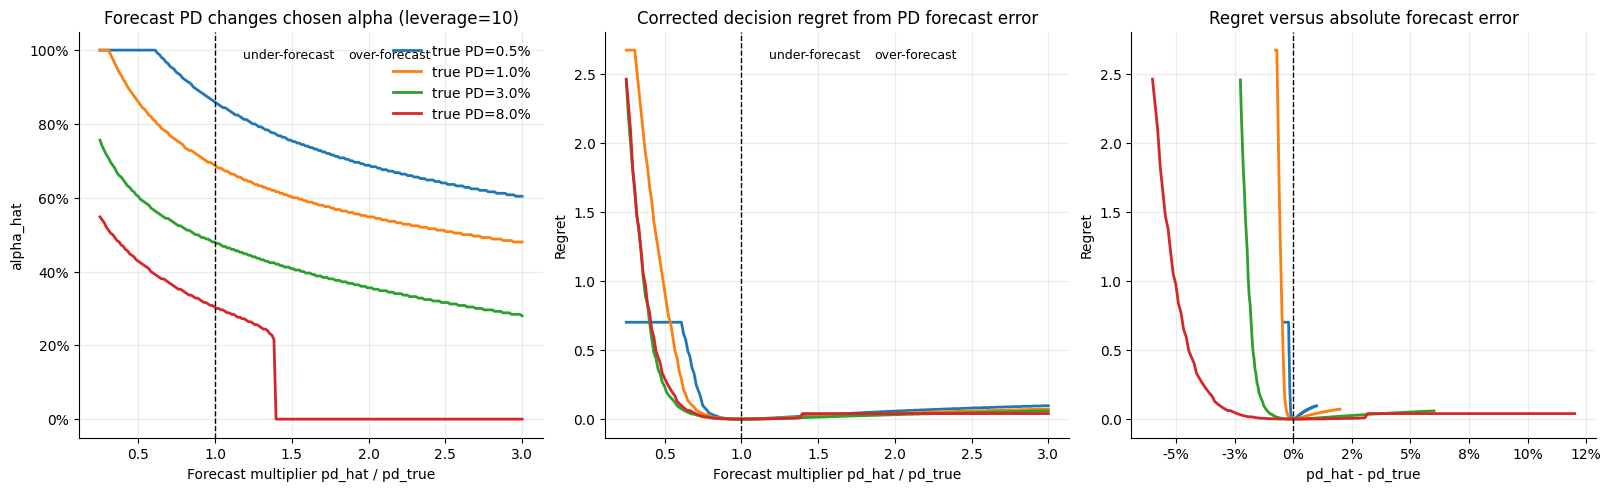

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for pd_true_value in true_pds:
    subset = forecast_diagnostics_df[forecast_diagnostics_df["pd_true"] == pd_true_value]
    label = f"true PD={100 * pd_true_value:.1f}%"
    axes[0].plot(subset["forecast_multiplier"], subset["alpha_hat"], lw=2, label=label)
    axes[1].plot(subset["forecast_multiplier"], subset["regret"], lw=2, label=label)
    axes[2].plot(subset["forecast_error"], subset["regret"], lw=2, label=label)

for ax in axes[:2]:
    ax.axvline(1, color="black", lw=1, ls="--")
    ax.text(0.55, 0.96, "under-forecast", transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.text(0.58, 0.96, "over-forecast", transform=ax.transAxes, ha="left", va="top", fontsize=9)

axes[0].set_title(f"Forecast PD changes chosen alpha (leverage={leverage:g})")
axes[0].set_xlabel("Forecast multiplier pd_hat / pd_true")
axes[0].set_ylabel("alpha_hat")
percent_axis(axes[0], "y")

axes[1].set_title("Corrected decision regret from PD forecast error")
axes[1].set_xlabel("Forecast multiplier pd_hat / pd_true")
axes[1].set_ylabel("Regret")

axes[2].axvline(0, color="black", lw=1, ls="--")
axes[2].set_title("Regret versus absolute forecast error")
axes[2].set_xlabel("pd_hat - pd_true")
axes[2].set_ylabel("Regret")
percent_axis(axes[2], "x")

axes[0].legend()
plt.show()

### 10.2 Regret heatmap over true PD and forecast PD

The heatmap below evaluates corrected regret over pairs `(pd_true, pd_hat)`. The x-axis is the forecasted PD used to choose the action. The y-axis is the true PD used to judge the consequence. The diagonal is the perfect-forecast line and should have approximately zero regret.

In [66]:
regret_heatmap_n = 60  # increase toward 80 for a smoother but slower heatmap
pd_true_heatmap_grid = np.linspace(0.001, 0.12, regret_heatmap_n)
pd_hat_heatmap_grid = np.linspace(0.001, 0.12, regret_heatmap_n)

regret_grid_results = evaluate_regret_grid(
    pd_true_heatmap_grid,
    pd_hat_heatmap_grid,
    rho_mode=rho_mode,
    rho_fixed=rho_fixed,
    alpha_grid=forecast_alpha_grid,
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
)

regret_matrix = regret_grid_results["regret_matrix"]
alpha_oracle_matrix = regret_grid_results["alpha_oracle_matrix"]
alpha_hat_matrix = regret_grid_results["alpha_hat_matrix"]
allocation_distortion_matrix = regret_grid_results["allocation_distortion_matrix"]
utility_oracle_matrix = regret_grid_results["utility_oracle_matrix"]
utility_hat_matrix = regret_grid_results["utility_hat_matrix"]

In [67]:
print("Minimum regret:", np.nanmin(regret_matrix))
print("Maximum regret:", np.nanmax(regret_matrix))
print("Fraction approximately zero:", np.mean(np.isclose(regret_matrix, 0.0, atol=1e-10)))

assert np.nanmin(regret_matrix) > -1e-9

diag_regrets = np.diag(regret_matrix)
print("Maximum diagonal regret:", np.nanmax(np.abs(diag_regrets)))
assert np.nanmax(np.abs(diag_regrets)) < 1e-8

Minimum regret: 0.0
Maximum regret: 16.93143897847848
Fraction approximately zero: 0.02277777777777778
Maximum diagonal regret: 0.0


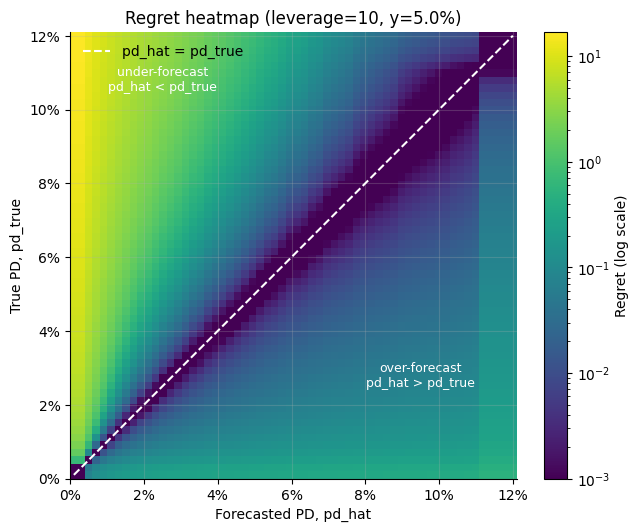

In [76]:
from matplotlib.colors import LogNorm


fig, ax = plt.subplots(figsize=(7.2, 5.8))
mesh = ax.pcolormesh(
    pd_hat_heatmap_grid,
    pd_true_heatmap_grid,
    regret_matrix + 1e-6,  # avoid log(0)
    shading="auto",
    cmap="viridis",
    norm=LogNorm(vmin=1e-3, vmax=regret_matrix.max()),
)
fig.colorbar(mesh, ax=ax, label="Regret (log scale)")
ax.plot(pd_hat_heatmap_grid, pd_hat_heatmap_grid, color="white", lw=1.5, ls="--", label="pd_hat = pd_true")
ax.text(0.025, 0.105, "under-forecast\npd_hat < pd_true", color="white", fontsize=9, ha="center")
ax.text(0.095, 0.025, "over-forecast\npd_hat > pd_true", color="white", fontsize=9, ha="center")
ax.set_title(f"Regret heatmap (leverage={leverage:g}, y={100*y:.1f}%)")
ax.set_xlabel("Forecasted PD, pd_hat")
ax.set_ylabel("True PD, pd_true")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(loc="upper left")
plt.show()





### 10.3 Allocation distortion heatmap

This heatmap shows `alpha_hat - alpha_oracle`. Negative values mean the forecast-based model under-allocates relative to the oracle. Positive values mean it over-allocates relative to the oracle.

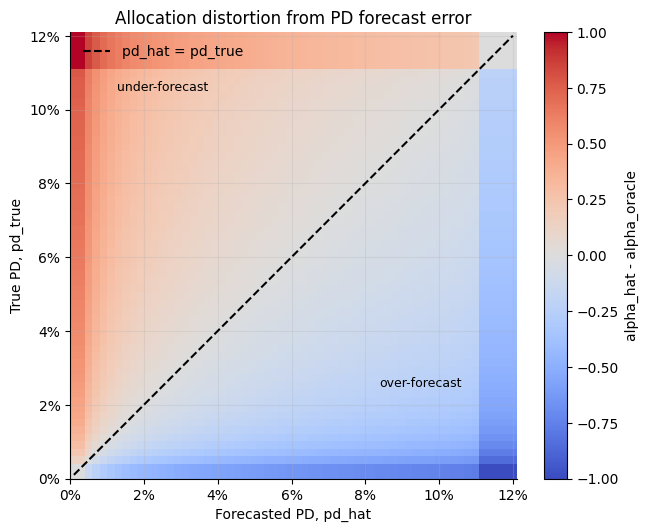

In [77]:
max_abs_distortion = np.nanmax(np.abs(allocation_distortion_matrix))

fig, ax = plt.subplots(figsize=(7.2, 5.8))
mesh = ax.pcolormesh(
    pd_hat_heatmap_grid,
    pd_true_heatmap_grid,
    allocation_distortion_matrix,
    shading="auto",
    cmap="coolwarm",
    vmin=-max_abs_distortion,
    vmax=max_abs_distortion,
)
fig.colorbar(mesh, ax=ax, label="alpha_hat - alpha_oracle")
ax.plot(pd_hat_heatmap_grid, pd_hat_heatmap_grid, color="black", lw=1.5, ls="--", label="pd_hat = pd_true")
ax.text(0.025, 0.105, "under-forecast", color="black", fontsize=9, ha="center")
ax.text(0.095, 0.025, "over-forecast", color="black", fontsize=9, ha="center")
ax.set_title("Allocation distortion from PD forecast error")
ax.set_xlabel("Forecasted PD, pd_hat")
ax.set_ylabel("True PD, pd_true")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(loc="upper left")
plt.show()

### 10.4 Decision-weighted loss curve

A symmetric prediction loss such as squared PD error can give the same penalty to over- and under-forecasting of the same magnitude. The downstream allocation problem usually does not. The curves below normalise squared prediction error and decision regret to a maximum of 1 for each fixed true PD.

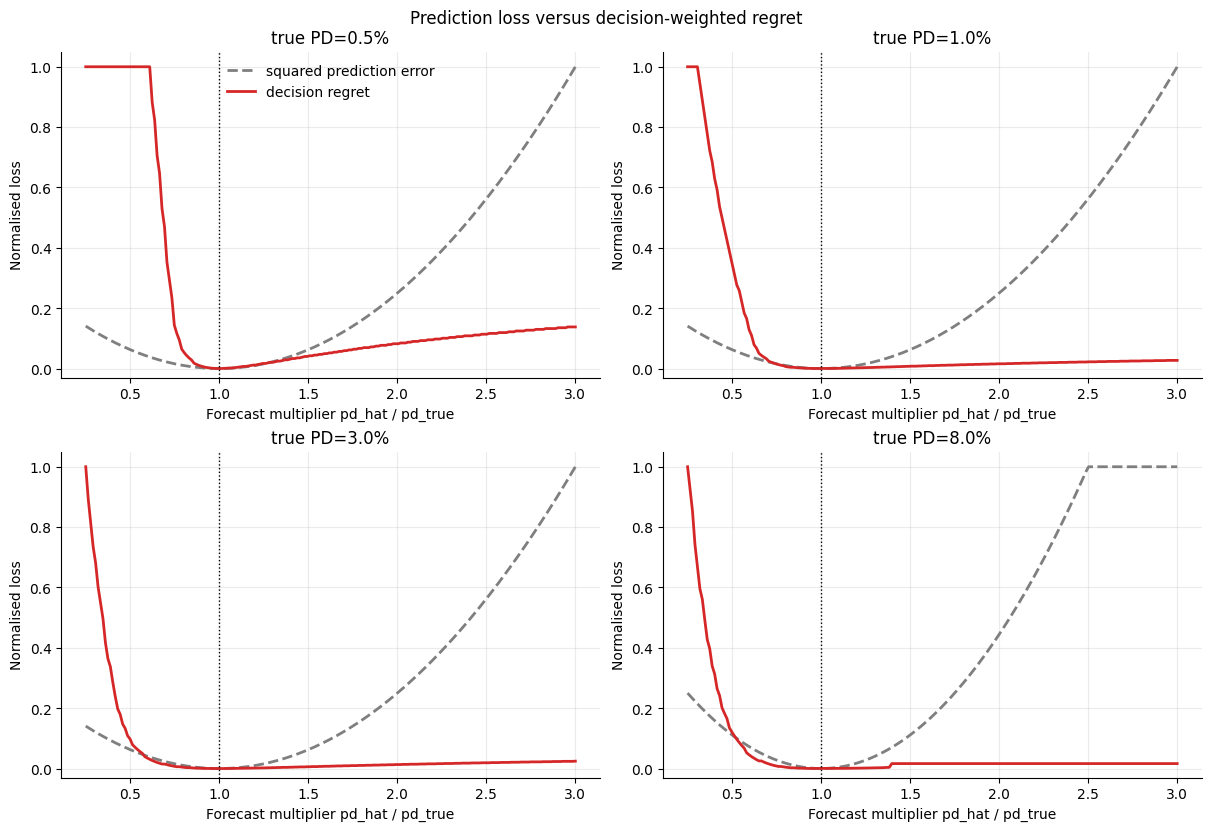

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

for ax, pd_true_value in zip(axes, true_pds):
    subset = forecast_diagnostics_df[forecast_diagnostics_df["pd_true"] == pd_true_value].copy()
    prediction_error_squared = subset["forecast_error"].to_numpy() ** 2
    decision_regret = subset["regret"].to_numpy()

    pred_norm = prediction_error_squared / prediction_error_squared.max() if prediction_error_squared.max() > 0 else prediction_error_squared
    regret_norm = decision_regret / decision_regret.max() if decision_regret.max() > 0 else decision_regret

    ax.plot(subset["forecast_multiplier"], pred_norm, color="tab:gray", lw=2, ls="--", label="squared prediction error")
    ax.plot(subset["forecast_multiplier"], regret_norm, color="tab:red", lw=2, label="decision regret")
    ax.axvline(1, color="black", lw=1, ls=":")
    ax.set_title(f"true PD={100 * pd_true_value:.1f}%")
    ax.set_xlabel("Forecast multiplier pd_hat / pd_true")
    ax.set_ylabel("Normalised loss")
    ax.set_ylim(-0.03, 1.05)

axes[0].legend()
fig.suptitle("Prediction loss versus decision-weighted regret", y=1.02)
plt.show()

### Interpretation for PTO versus DFL

In a predict-then-optimise approach, the model is trained to minimise a prediction loss on PD, such as MSE or calibration error. This treats forecast errors symmetrically unless the loss is explicitly weighted.

However, the downstream allocation problem does not treat all PD errors equally. An under-forecast of PD may lead to excessive risky allocation and regulatory shortfall, while an over-forecast may lead to conservative under-allocation and opportunity cost. The regret heatmap visualises this decision-dependent error surface.

Decision-focused learning would train the predictive model using this downstream regret or utility loss directly, rather than only trying to make PD forecasts accurate in a statistical sense.

## 11. Optional comparison: linear versus squared penalty

This comparison is exploratory only. The linear analytical expected-shortfall penalty is the main thesis expression. The squared penalty below uses Monte Carlo systematic-factor draws and a coarser PD grid to keep runtime modest.

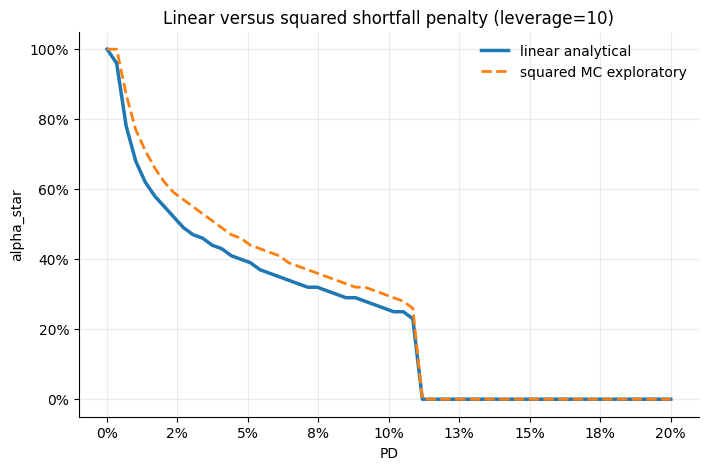

In [71]:
mc_draws = rng.standard_normal(15_000)

linear_curve = alpha_star_curve(
    coarse_pd_grid,
    rho_mode="basel",
    rho_fixed=rho_fixed,
    penalty_type="linear",
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    alpha_grid=coarse_alpha_grid,
)

squared_curve = alpha_star_curve(
    coarse_pd_grid,
    rho_mode="basel",
    rho_fixed=rho_fixed,
    penalty_type="squared_mc",
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    mc_draws=mc_draws,
    alpha_grid=coarse_alpha_grid,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coarse_pd_grid, linear_curve, lw=2.5, label="linear analytical")
ax.plot(coarse_pd_grid, squared_curve, lw=2, ls="--", label="squared MC exploratory")
ax.set_title(f"Linear versus squared shortfall penalty (leverage={leverage:g})")
ax.set_xlabel("PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

## Summary: what to look for

- `K_IRB(PD)` rises nonlinearly because the regulatory capital formula combines expected default risk, tail confidence, correlation, and maturity adjustment.
- Basel corporate correlation `R(PD)` changes with PD, so the Vasicek tail is not driven by PD alone in the baseline setting.
- The Vasicek tail thickens as PD and rho change, which affects the probability and severity of breaching the shortfall threshold.
- High PD reduces alpha through direct expected losses and through the regulatory shortfall penalty when losses exceed the threshold.
- Larger `lambda_penalty` lowers risky allocation, larger yield raises it, and fixed-rho experiments help separate correlation mechanics from the Basel-implied case.